# 05: Jaynes-Cummings Ultra-strong Coupling

XXX Description

## Tasks

- XXX

# Imports

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
import qutip
import numpy as np

## Helper functions

In [3]:
def jcm_h(wc, wa, g, N, atom):
    """ Construct the Jaynes-Cummings Hamiltonian (non-RWA). """
    a = qutip.tensor(qutip.destroy(N), qutip.qeye(2))
    sm = qutip.tensor(qutip.qeye(N), qutip.destroy(2))
    atom = qutip.tensor(qutip.qeye(N), atom)
    
    H = wc * a.dag() * a + wa * atom + g * (a.dag() + a) * (sm + sm.dag())
    return H

In [4]:
def display_eigenstates(op):
    """ Display the eigenvalues and eigenstates of an operator. """
    evals, evecs = op.eigenstates()
    print("Eigenvalues:", evals)
    print()
    print("Eigenstates")
    print("===========")
    for v in evecs:
        display(v)

# XXX

In [5]:
# Dissipation parameters
# We use stronger dissipation to show long-term behaviour in shorter times
kappa = 0.2 # cavity dissipation rate
gamma = 0.2 # atom dissipation rate
n_th_a = 0 # avg number of thermal bath excitation

In [6]:
# system parameters
wc = 1.0 #* 2 * np.pi  # cavity frequency
wa = 1.0 #* 2 * np.pi  # atom frequency
N = 8  # 15 # number of cavity fock states
# g = 0.05 * 2 * np.pi  # coupling strength
g = 0.1

# Atom hamiltonian
H_atom = 0.5 * qutip.sigmaz()

In [7]:
def jcm_c_ops(N, n_th_a):
    """ Return basic JCM collapse operators. """
    c_ops = []

    sm = qutip.tensor(qutip.qeye(N), qutip.sigmam())
    a = qutip.tensor(qutip.destroy(N), qutip.qeye(2))

    # cavity relaxation
    rate = kappa * (1 + n_th_a)
    if rate > 0.0:
        c_ops.append(np.sqrt(rate) * a)

    # cavity excitation, if temperature > 0
    rate = kappa * n_th_a
    if rate > 0.0:
        c_ops.append(np.sqrt(rate) * a.dag())

    # qubit relaxation
    rate = gamma
    if rate > 0.0:
        c_ops.append(np.sqrt(rate) * sm)
        
    return c_ops

In [8]:
def matrix_element(a, x, b):
    """ Return <a|x|b>. """
    return (a * x * b).norm()

In [9]:
def jcm_c_ops_from_eigenstates(H, N, n_th_a, n_levels=None):
    """ Return full JCM collapse operators. """
    sx = qutip.tensor(qutip.qeye(N), qutip.sigmax())
    a = qutip.tensor(qutip.destroy(N), qutip.qeye(2))
    x = a + a.dag()

    energies, eigenstates = H.eigenstates()
    n_energies = len(energies)
    if n_levels is not None:
        n_energies = min(n_energies, n_levels)

    c_ops = []

    for j in range(n_energies):
        for k in range(j, n_energies):
            rate = matrix_element(eigenstates[j].dag(), x, eigenstates[k])**2 * kappa
            if rate > 0.0:
                c_ops.append(np.sqrt(rate) * eigenstates[j] * eigenstates[k].dag())

            rate = matrix_element(eigenstates[j].dag(), sx, eigenstates[k])**2 * gamma
            if rate > 0.0:
                c_ops.append(np.sqrt(rate) * eigenstates[j] * eigenstates[k].dag())

    return c_ops

In [10]:
def jcm_brmesolve(H, psi0, tlist, kappa, gamma, N, e_ops, options):
    """ Solve the given Jaynes-Cummings model use the Bloch-Redfield solver. """
    sx = qutip.tensor(qutip.qeye(N), qutip.sigmax())
    a = qutip.tensor(qutip.destroy(N), qutip.qeye(2))
    x = a + a.dag()

    cavity_spectrum = "0 if (w <= 0) else {kappa}".format(kappa=kappa)
    atom_spectrum = "0 if (w <= 0) else {gamma}".format(gamma=gamma)
    a_ops = [
        [x, cavity_spectrum],
        [sx, atom_spectrum],
    ]

    result = qutip.brmesolve(H, psi0, tlist, a_ops=a_ops, e_ops=e_ops, options=options)
    return result

In [11]:
g = 0.01  # g_values[0]
H = jcm_h(wc, wa, g, N, H_atom)

display_eigenstates(H)

Eigenvalues: [-0.50005     0.48995012  0.50994987  1.48580821  1.51409178  2.48263013
  2.51726985  3.47995099  3.51994899  4.47759071  4.52230927  5.47545696
  5.52444308  6.47369407  6.52660598  7.50034999]

Eigenstates


Quantum object: dims = [[8, 2], [1, 1]], shape = (16, 1), type = ket
Qobj data =
[[ 0.00000000e+00]
 [-9.99987499e-01]
 [ 5.00006250e-03]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [-3.53562229e-05]
 [ 1.53098850e-07]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [-7.65500484e-10]
 [ 2.85289406e-12]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 0.00000000e+00]]

Quantum object: dims = [[8, 2], [1, 1]], shape = (16, 1), type = ket
Qobj data =
[[ 7.05336776e-01]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [-7.08854818e-01]
 [ 4.98766997e-03]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [-4.29806576e-05]
 [ 2.14371369e-07]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [-1.19539882e-09]
 [ 4.87212909e-12]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 0.00000000e+00]]

Quantum object: dims = [[8, 2], [1, 1]], shape = (16, 1), type = ket
Qobj data =
[[ 7.08872366e-01]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 7.05318964e-01]
 [-5.01267380e-03]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 4.36302734e-05]
 [-2.18702233e-07]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 1.22566214e-09]
 [-5.01215407e-12]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 0.00000000e+00]]

Quantum object: dims = [[8, 2], [1, 1]], shape = (16, 1), type = ket
Qobj data =
[[ 0.00000000e+00]
 [-3.54814447e-03]
 [-7.04593443e-01]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 7.09576104e-01]
 [-6.10241323e-03]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 6.05979101e-05]
 [-3.37567558e-07]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 2.05992212e-09]
 [-9.06196851e-12]
 [ 0.00000000e+00]]

...

Quantum object: dims = [[8, 2], [1, 1]], shape = (16, 1), type = ket
Qobj data =
[[ 0.00000000e+00]
 [ 2.08910939e-12]
 [ 1.24833618e-09]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 3.50914883e-07]
 [ 8.05420577e-05]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 7.95506452e-03]
 [ 7.02719098e-01]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [-7.11362184e-01]
 [ 9.29635673e-03]
 [ 0.00000000e+00]]

Quantum object: dims = [[8, 2], [1, 1]], shape = (16, 1), type = ket
Qobj data =
[[ 0.00000000e+00]
 [-1.94903996e-12]
 [-1.17418031e-09]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [-3.34136405e-07]
 [-7.76360793e-05]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [-7.85820180e-03]
 [-7.11379515e-01]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [-7.02701119e-01]
 [ 9.41087746e-03]
 [ 0.00000000e+00]]

Quantum object: dims = [[8, 2], [1, 1]], shape = (16, 1), type = ket
Qobj data =
[[ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [-5.14971133e-12]
 [-2.17525235e-09]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [-4.99045092e-07]
 [-9.91507423e-05]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [-8.75122103e-03]
 [-7.05045450e-01]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 7.09108116e-01]]

Quantum object: dims = [[8, 2], [1, 1]], shape = (16, 1), type = ket
Qobj data =
[[0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [4.74181119e-12]
 [2.02069544e-09]
 [0.00000000e+00]
 [0.00000000e+00]
 [4.69759734e-07]
 [9.45751177e-05]
 [0.00000000e+00]
 [0.00000000e+00]
 [8.57116624e-03]
 [7.09056325e-01]
 [0.00000000e+00]
 [0.00000000e+00]
 [7.05099747e-01]]

Quantum object: dims = [[8, 2], [1, 1]], shape = (16, 1), type = ket
Qobj data =
[[ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [-1.30673852e-11]
 [-4.52691393e-09]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [-9.05450688e-07]
 [-1.61982066e-04]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [-1.32272682e-02]
 [-9.99912503e-01]
 [ 0.00000000e+00]]

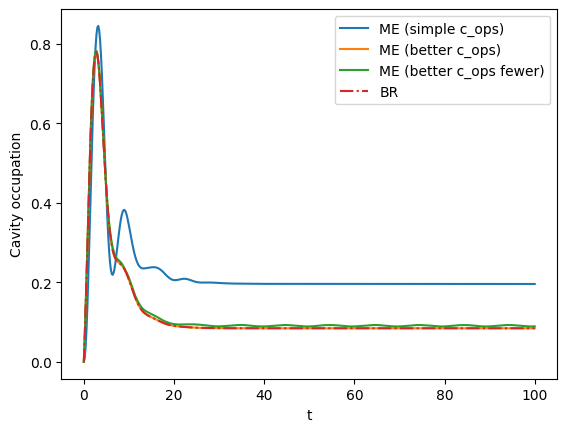

In [12]:
g = 0.5

H = jcm_h(wc, wa, g, N, H_atom)

tlist = np.linspace(0, 100, 500)

gnd_energy, gnd_state = H.groundstate()
psi0 = qutip.tensor(qutip.basis(N, 0), qutip.basis(2, 0))
# psi0 = qutip.tensor(qutip.basis(N, 0), qutip.basis(2, 1))
# psi0 = gnd_state

sm = qutip.tensor(qutip.qeye(N), qutip.sigmam())
a = qutip.tensor(qutip.destroy(N), qutip.qeye(2))
e_ops = [a.dag() * a, sm.dag() * sm]

c_ops_simple = jcm_c_ops(N, n_th_a)
c_ops_better = jcm_c_ops_from_eigenstates(H, N, n_th_a)
c_ops_better_fewer = jcm_c_ops_from_eigenstates(H, N, n_th_a, n_levels=5)

options = qutip.Options(nsteps=15000, store_states=True, rtol=1e-12, atol=1e-12)

result_br = jcm_brmesolve(H, psi0, tlist, kappa, gamma, N, e_ops=e_ops, options=options)
result_me_simple = qutip.mesolve(H, psi0, tlist, c_ops=c_ops_simple, e_ops=e_ops, options=options)
result_me_better = qutip.mesolve(H, psi0, tlist, c_ops=c_ops_better, e_ops=e_ops, options=options)
result_me_better_fewer = qutip.mesolve(H, psi0, tlist, c_ops=c_ops_better_fewer, e_ops=e_ops, options=options)

plt.plot(tlist, result_me_simple.expect[0], label="ME (simple c_ops)")
plt.plot(tlist, result_me_better.expect[0], label="ME (better c_ops)")
plt.plot(tlist, result_me_better_fewer.expect[0], label="ME (better c_ops fewer)")
plt.plot(tlist, result_br.expect[0], "-.", label="BR")
plt.xlabel("t")
plt.ylabel("Cavity occupation")
plt.legend();

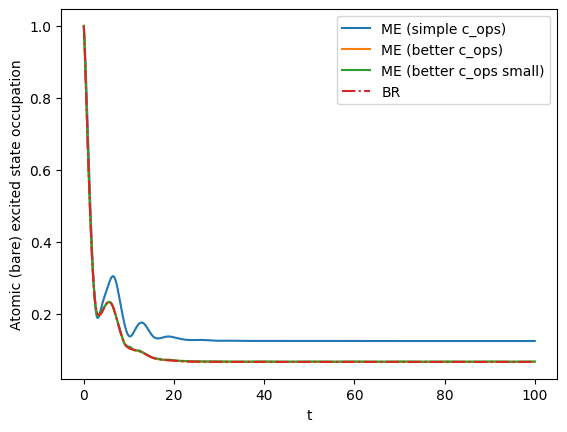

In [13]:
plt.plot(tlist, result_me_simple.expect[1], label="ME (simple c_ops)")
plt.plot(tlist, result_me_better.expect[1], label="ME (better c_ops)")
plt.plot(tlist, result_me_better_fewer.expect[1], label="ME (better c_ops small)")
plt.plot(tlist, result_br.expect[1], "-.", label="BR")
plt.xlabel("t")
plt.ylabel("Atomic (bare) excited state occupation")
plt.legend();

## Explain the expectation values here!

In [14]:
a.dag() * a

Quantum object: dims = [[8, 2], [8, 2]], shape = (16, 16), type = oper, isherm = True
Qobj data =
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 2. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 2. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 3. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 3. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 4. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 4. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 5. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 5. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 6. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 6. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 7. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 7.]]

In [15]:
sm.dag() * sm

Quantum object: dims = [[8, 2], [8, 2]], shape = (16, 16), type = oper, isherm = True
Qobj data =
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]